# Testing BaselineGNN - 2 layer conv nn on atom features only with relu activation functions

[21:33:30] Explicit valence for atom # 9 N, 5, is greater than permitted
Sanitization failed for molecule at index 2131, Name: ZINC16448882. Skipping sanitization: Explicit valence for atom # 9 N, 5, is greater than permitted
[21:33:30] Explicit valence for atom # 7 N, 5, is greater than permitted
Sanitization failed for molecule at index 2721, Name: ZINC15772239. Skipping sanitization: Explicit valence for atom # 7 N, 5, is greater than permitted
[21:33:30] Explicit valence for atom # 10 N, 5, is greater than permitted
Sanitization failed for molecule at index 3249, Name: ZINC11539132. Skipping sanitization: Explicit valence for atom # 10 N, 5, is greater than permitted
[21:33:30] Explicit valence for atom # 3 N, 5, is greater than permitted
Sanitization failed for molecule at index 5699, Name: ZINC17111082. Skipping sanitization: Explicit valence for atom # 3 N, 5, is greater than permitted
Skipping molecule ZINC59391023: Missing from JSON.
Skipping molecule ZINC00335972: Missing fro

num_node_features = 136
num_y_ATs = 75
FULL DATASET:


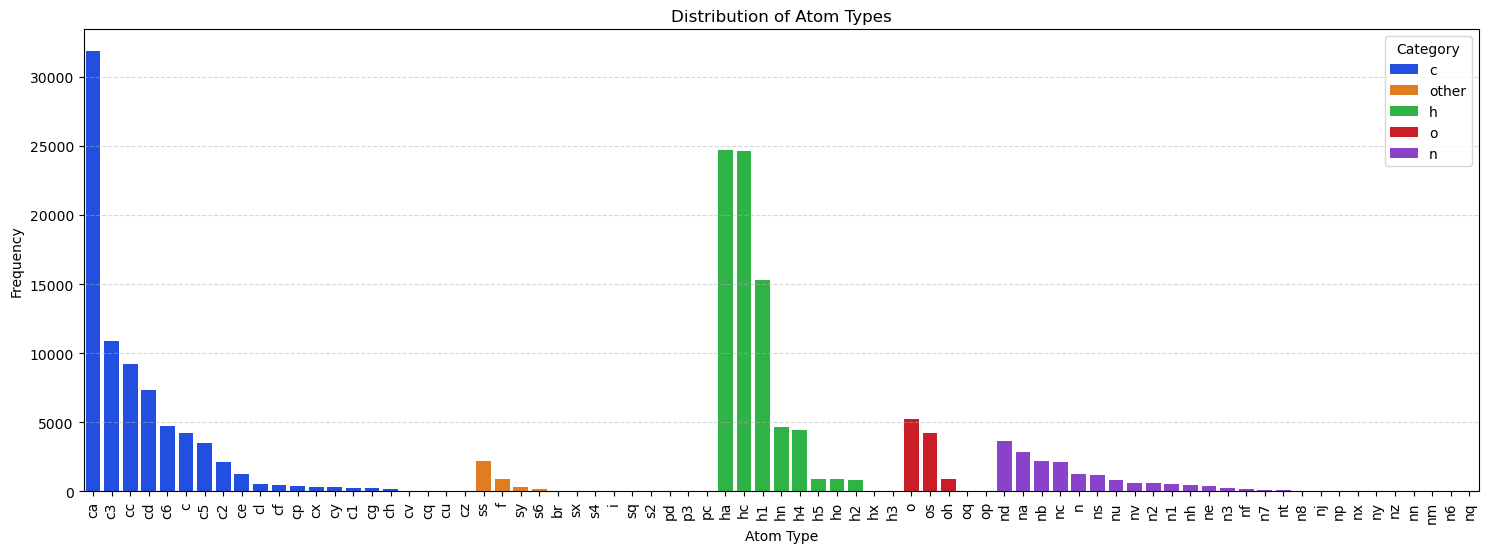

BaselineGNN - Number of parameters: 17803
Epoch: 1/20


Epoch 1: Loss = 453.6060
Epoch: 2/20


Epoch 2: Loss = 259.5881
Epoch: 3/20


Epoch 3: Loss = 223.2369
Epoch: 4/20


Epoch 4: Loss = 207.7702
Epoch: 5/20


...

Epoch 16: Loss = 166.7472
Epoch: 17/20


Epoch 17: Loss = 165.8835
Epoch: 18/20


Epoch 18: Loss = 164.9179
Epoch: 19/20


Epoch 19: Loss = 163.9428
Epoch: 20/20


Epoch 20: Loss = 163.1655


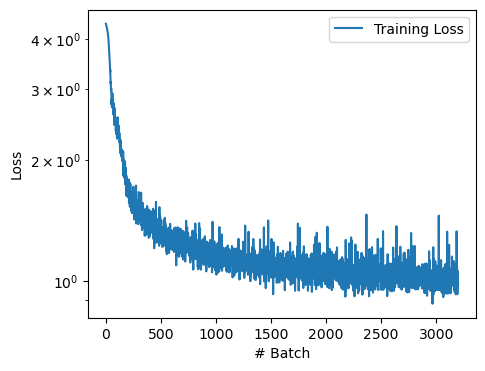

Evaluation Metrics: {'Accuracy': 0.6545503211991435, 'F1-score': 0.6096660092893302}


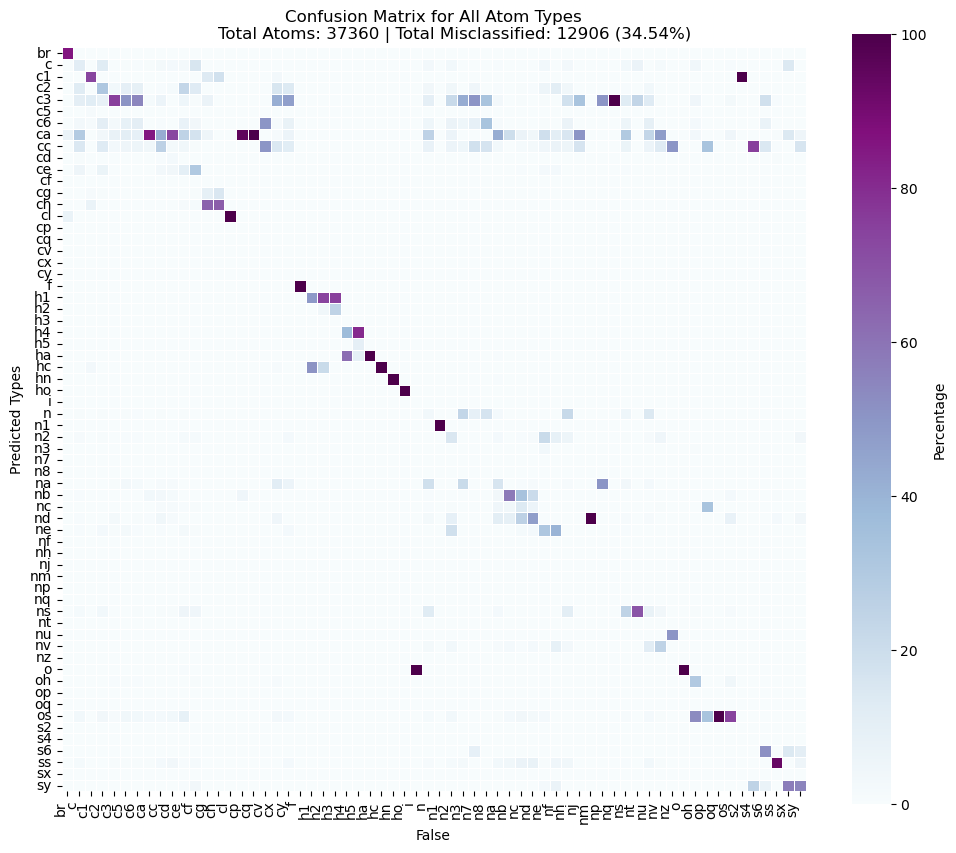

In [1]:
from atoMLtype.RF.GNNmodel import GNNTrainer, BaselineGNN
from atoMLtype.RF.GNNdataset import GNNdataset
from atoMLtype.RF.metrics import plot_atom_distribution, plot_full_confusion_matrix
from torch.utils.data import random_split
import numpy as np

# Load the SDF file
sdf_path = "./data/parm_at_Frosst/zinc.sdf"
json_labels = "./data/antechamber/atomLabels_gaff2.json"

# Initialize dataset
gnn_test_dataset = GNNdataset(sdf_path, json_labels)
num_node_feat = gnn_test_dataset[0].x.shape[1]
num_y_ATs = len(set(gnn_test_dataset.all_labels))

print(f"num_node_features = {num_node_feat}")
print(f"num_y_ATs = {num_y_ATs}")


# Split Train and test dataset (80% train, 20% test)
train_size = int(0.8 * len(gnn_test_dataset))
test_size = len(gnn_test_dataset) - train_size
train_dataset, test_dataset = random_split(gnn_test_dataset, [train_size, test_size])

print("FULL DATASET:")
plot_atom_distribution(np.array(gnn_test_dataset.all_labels))

# Initialize baselineGNN for classification
model = BaselineGNN(num_node_features=num_node_feat, num_atom_types=num_y_ATs)
trainer = GNNTrainer(model, train_dataset, test_dataset, batch_size=32, learning_rate=0.001, epochs=20, task="classification")

trainer.train()
metrics = trainer.evaluate()

y_true_labels, y_pred_labels = trainer.predict()

plot_full_confusion_matrix(y_true=y_true_labels, y_pred=y_pred_labels)


GNNWithEmbeddings - Number of parameters: 20027
Epoch: 1/20


Epoch 1: Loss = 358.6828
Epoch: 2/20


Epoch 2: Loss = 151.6463
Epoch: 3/20


Epoch 3: Loss = 123.8125
Epoch: 4/20


Epoch 4: Loss = 110.4106
Epoch: 5/20


...

Epoch 16: Loss = 53.1812
Epoch: 17/20


Epoch 17: Loss = 51.8540
Epoch: 18/20


Epoch 18: Loss = 50.7101
Epoch: 19/20


Epoch 19: Loss = 49.8686
Epoch: 20/20


Epoch 20: Loss = 48.8339


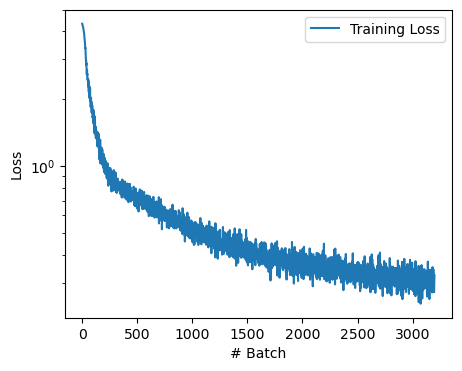

Evaluation Metrics: {'Accuracy': 0.8763115631691649, 'F1-score': 0.8735633677798259}


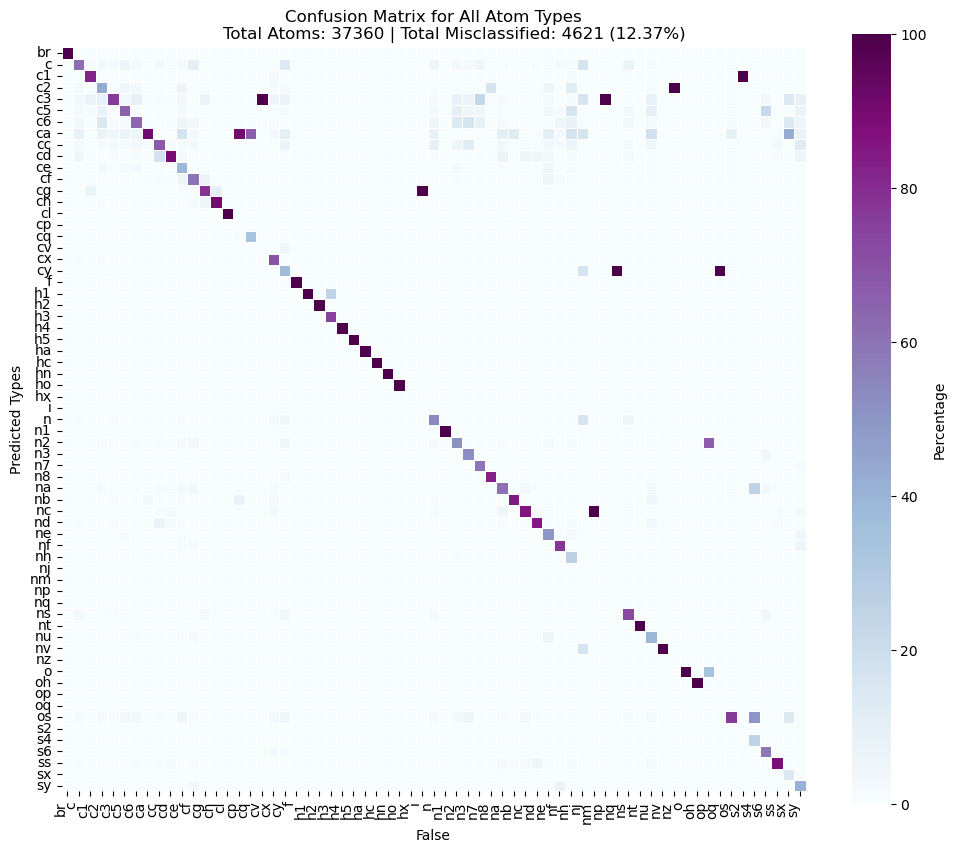

In [2]:
import importlib
import atoMLtype.RF.GNNmodel  # First import it normally
importlib.reload(atoMLtype.RF.GNNmodel)
from atoMLtype.RF.GNNmodel import GNNWithEmbeddings

# Initialize baselineGNN for classification
model_embeddings = GNNWithEmbeddings(num_node_features=num_node_feat, num_atom_types=num_y_ATs, embedding_dim=16, hidden_dim=64)
trainer_embeddings = GNNTrainer(model_embeddings, train_dataset, test_dataset, batch_size=32, learning_rate=0.001, epochs=20, task="classification")

trainer_embeddings.train()
metrics_embeddings = trainer_embeddings.evaluate()

y_true_labels_embeddings, y_pred_labels_embeddings = trainer_embeddings.predict()

plot_full_confusion_matrix(y_true=y_true_labels_embeddings, y_pred=y_pred_labels_embeddings)

GNNWithEmbeddings - Number of parameters: 20027
Epoch: 1/20


Epoch 1: Loss = 36.0487
Epoch: 2/20


Epoch 2: Loss = 35.7813
Epoch: 3/20


Epoch 3: Loss = 35.6295
Epoch: 4/20


Epoch 4: Loss = 35.5778
Epoch: 5/20


...

Epoch 16: Loss = 34.4361
Epoch: 17/20


Epoch 17: Loss = 34.3876
Epoch: 18/20


Epoch 18: Loss = 34.2026
Epoch: 19/20


Epoch 19: Loss = 34.1425
Epoch: 20/20


Epoch 20: Loss = 34.0658


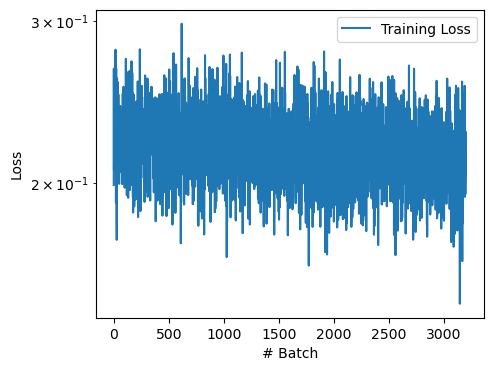

Evaluation Metrics: {'Accuracy': 0.8986081370449679, 'F1-score': 0.8966693177990233}


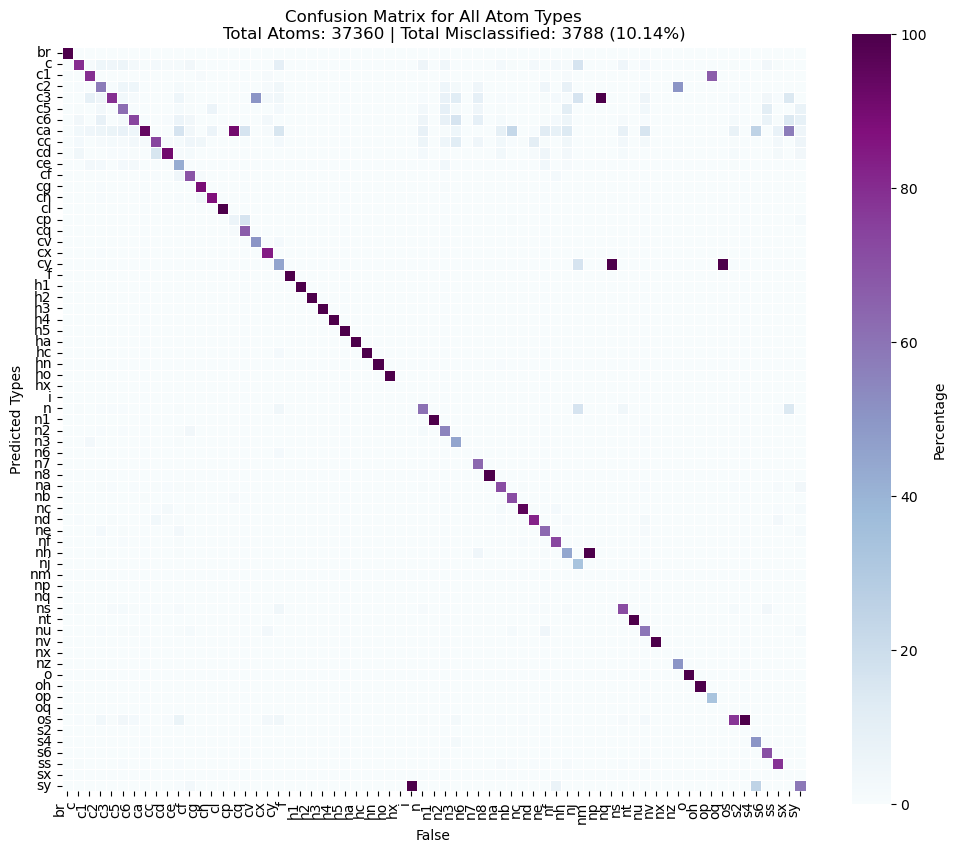

In [ ]:
import importlib
import atoMLtype.RF.GNNmodel  # First import it normally
importlib.reload(atoMLtype.RF.GNNmodel)
from atoMLtype.RF.GNNmodel import GNNWithGAT

# Initialize baselineGNN for classification
model_embeddings_GAT = GNNWithGAT(num_node_features=num_node_feat, num_atom_types=num_y_ATs, embedding_dim=16, hidden_dim=64, heads=4)
trainer_embeddings_GAT = GNNTrainer(model_embeddings, train_dataset, test_dataset, batch_size=32, learning_rate=0.001, epochs=20, task="classification")

trainer_embeddings_GAT.train()
metrics_embeddings_GAT = trainer_embeddings_GAT.evaluate()

y_true_embeddings_GAT, y_pred_embeddings_GAT = trainer_embeddings_GAT.predict()

plot_full_confusion_matrix(y_true=y_true_embeddings_GAT, y_pred=y_pred_embeddings_GAT)


In [ ]:
from atoMLtype.RF.metrics import plot_category_confusion_matrix

plot_category_confusion_matrix(y_pred=y_pred_embeddings_GAT, y_true= y_true_embeddings_GAT)

# What are the common fingerprints for the different atom types
1. Are the rings something to consider?
2. What about functional group as immediate substituents?
3. 